# ***Importing libraries and modules***

---



In [ ]:
!pip install -q numpy scipy scikit-image pillow tqdm pandas torchvision


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 43.1 MB/s eta 0:00:00


# ***SVT***

---



In [ ]:
%%writefile svt_image_completion.py
"""
SVT Image Completion (v2 – resize option)
----------------------------------------
* Recursive image discovery
* Optional down‑scaling before SVT via `--max-dim` (speeds up BSDS).
* Kick‑start: Y₀ = δ·PΩ(M) avoids ARPACK –9.
* Saves 8‑bit PNG with PIL.
"""
from __future__ import annotations
import argparse
from pathlib import Path
from typing import List, Tuple

import numpy as np
from numpy.typing import NDArray
from scipy.sparse.linalg import svds
from skimage import color
from skimage.transform import resize
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
from tqdm import tqdm
from PIL import Image

# ─────────────────────────  SVT core  ─────────────────────────

def svt(M: NDArray[np.floating], mask: NDArray[np.bool_], *,
        tau: float, delta: float, eps: float = 1e-4, max_iter: int = 500,
        increment: int = 5) -> Tuple[NDArray[np.floating], int]:
    """Singular‑Value‑Thresholding with kicking initialisation."""
    Y = delta * (M * mask)  # Y₀ = δ·PΩ(M) (Eq. 5.3)
    rk = 0
    n1, n2 = M.shape
    for k in range(1, max_iter + 1):
        sk = rk + 1
        while True:
            u, s, vt = svds(Y, k=sk, which='LM')
            s, u, vt = s[::-1], u[:, ::-1], vt[::-1, :]
            if s[-1] <= tau or sk >= min(n1, n2):
                break
            sk += increment
        above = s > tau
        rk = int(above.sum())
        X = np.zeros_like(M) if rk == 0 else (u[:, above] @ np.diag(s[above] - tau)) @ vt[above, :]
        if np.linalg.norm((X - M)[mask]) / np.linalg.norm(M[mask]) <= eps:
            return X, k
        Y[mask] += delta * (M[mask] - X[mask])
    return X, max_iter

# ───────────────────────  masks  ───────────────────────

def random_mask(shape: Tuple[int, int], rate: float, rng: np.random.Generator):
    return rng.random(shape) < (1.0 - rate)

def center_mask(h: int, w: int, rate: float):
    bh, bw = int(h * (1 - rate) / 2), int(w * (1 - rate) / 2)
    m = np.ones((h, w), bool)
    m[bh:h - bh, bw:w - bw] = False
    return m

# ───────────────────────  loader  ───────────────────────

def load_images(dataset: str, root: Path, max_images: int | None) -> List[NDArray[np.floating]]:
    imgs: List[NDArray[np.floating]] = []

    if dataset == "usc-sipi":
        paths = list(root.rglob("*.tif")) + list(root.rglob("*.tiff"))
    elif dataset in {"bsds500", "caltech101"}:
        paths = list(root.rglob("*.jpg"))
    elif dataset == "cifar10":
        import torchvision.transforms as T, torchvision.datasets as dset
        tf = T.ToTensor()
        ds = dset.CIFAR10(root=str(root), train=False, transform=tf, download=True)
        for i in range(len(ds)):
            if max_images is not None and i >= max_images:
                break
            imgs.append(color.rgb2gray(ds[i][0].permute(1, 2, 0).numpy()))
        return imgs
    else:
        raise ValueError("unknown dataset")

    for p in paths[:max_images]:
        im = Image.open(p).convert('L')
        imgs.append(np.asarray(im, dtype=float) / 255.0)
    return imgs

# ───────────────────────  runner  ───────────────────────

def run(args: argparse.Namespace):
    rng = np.random.default_rng(0)
    root = Path(args.root)
    imgs = load_images(args.dataset, root, args.max_images)
    out_dir = Path(args.output); out_dir.mkdir(parents=True, exist_ok=True)

    results = []
    for idx, img in enumerate(tqdm(imgs, desc="images")):
        # optional down‑scaling
        if args.max_dim is not None and max(img.shape) > args.max_dim:
            scale = args.max_dim / max(img.shape)
            img = resize(img, (int(img.shape[0]*scale), int(img.shape[1]*scale)),
                         anti_aliasing=True, preserve_range=True)

        h, w = img.shape
        mask = random_mask((h, w), args.mask_rate, rng) if args.mask == "random" else center_mask(h, w, args.mask_rate)
        tau = args.tau_scale * min(h, w)
        delta = args.delta_scale / mask.mean()

        X_hat, iters = svt(img, mask, tau=tau, delta=delta,
                           eps=args.eps, max_iter=args.max_iter,
                           increment=args.increment)

        for tag, arr in zip(["orig", "mask", "svt"], [img, img*mask + (1-mask), X_hat]):
            Image.fromarray((np.clip(arr, 0, 1)*255).astype(np.uint8)).save(out_dir / f"img_{idx:03d}_{tag}.png")

        results.append((idx, iters,
                        psnr((img*255).astype(np.uint8), (X_hat*255).astype(np.uint8), data_range=255),
                        ssim((img*255).astype(np.uint8), (X_hat*255).astype(np.uint8), data_range=255)))

    import pandas as pd
    df = pd.DataFrame(results, columns=["id", "iters", "psnr", "ssim"])
    df.to_csv(out_dir / "summary.csv", index=False)
    print(f"\nProcessed {len(imgs)} images. Avg PSNR: {df.psnr.mean():.2f} dB; SSIM: {df.ssim.mean():.3f}")

# ───────────────────────  CLI  ───────────────────────

def cli():
    p = argparse.ArgumentParser()
    p.add_argument("--dataset", required=True, choices=["cifar10", "usc-sipi", "bsds500", "caltech101"])
    p.add_argument("--root", required=True)
    p.add_argument("--mask", choices=["random", "center"], default="random")
    p.add_argument("--mask-rate", type=float, default=0.5)
    p.add_argument("--max-dim", type=int, default=None, help="Resize so max(H,W)=this (keeps aspect)")
    p.add_argument("--tau-scale", type=float, default=5.0)
    p.add_argument("--delta-scale", type=float, default=1.2)
    p.add_argument("--eps", type=float, default=1e-4)
    p.add_argument("--max-iter", type=int, default=500)
    p.add_argument("--increment", type=int, default=5)
    p.add_argument("--max-images", type=int, default=10)
    p.add_argument("--output", default="svt_results")
    run(p.parse_args())

if __name__ == "__main__":
    cli()


Writing svt_image_completion.py


# ***CIFAR10***

---



In [ ]:
!mkdir -p /content/datasets


## ***Mask Rate = 50%***

In [ ]:
!python svt_image_completion.py \
        --dataset cifar10 \
        --root /content/datasets \
        --mask random --mask-rate 0.5 \
        --max-images 50 \
        --max-dim 256 \
        --output /content/results_cifar_mask_rate_50


100% 170M/170M [00:06<00:00, 28.4MB/s]
images: 100% 50/50 [01:08<00:00,  1.38s/it]

Processed 50 images. Avg PSNR: 18.97 dB; SSIM: 0.651


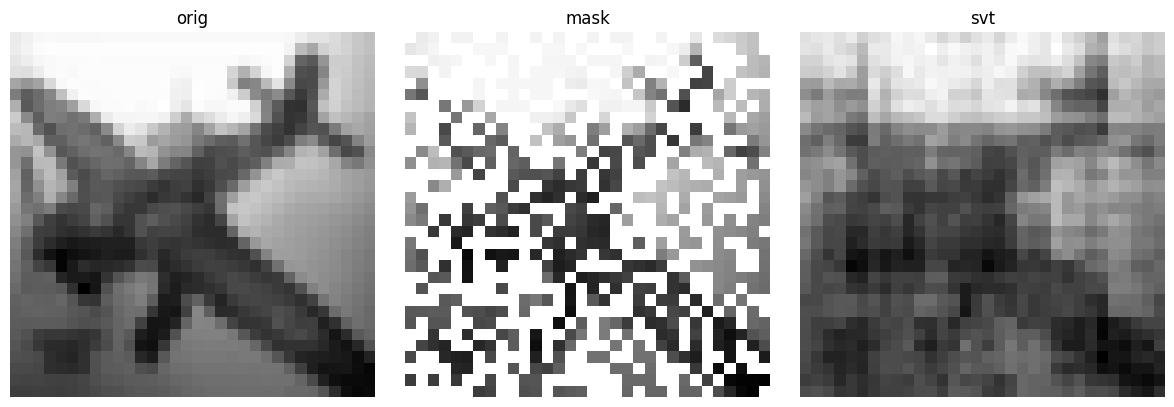

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(12,4))
for i, tag in enumerate(["orig", "mask", "svt"]):
    axs[i].imshow(Image.open(f"/content/results_cifar_mask_rate_50/img_027_{tag}.png"), cmap="gray")
    axs[i].set_title(tag); axs[i].axis("off")
plt.tight_layout()

In [ ]:
from google.colab import files
files.download('/content/results_cifar_mask_rate_50/summary.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## ***Mask Rate = 40%***

In [ ]:
!python svt_image_completion.py \
        --dataset cifar10 \
        --root /content/datasets \
        --mask random --mask-rate 0.4 \
        --max-images 50 \
        --max-dim 256 \
        --output /content/results_cifar_mask_rate_40

images: 100% 50/50 [00:45<00:00,  1.09it/s]

Processed 50 images. Avg PSNR: 24.00 dB; SSIM: 0.858


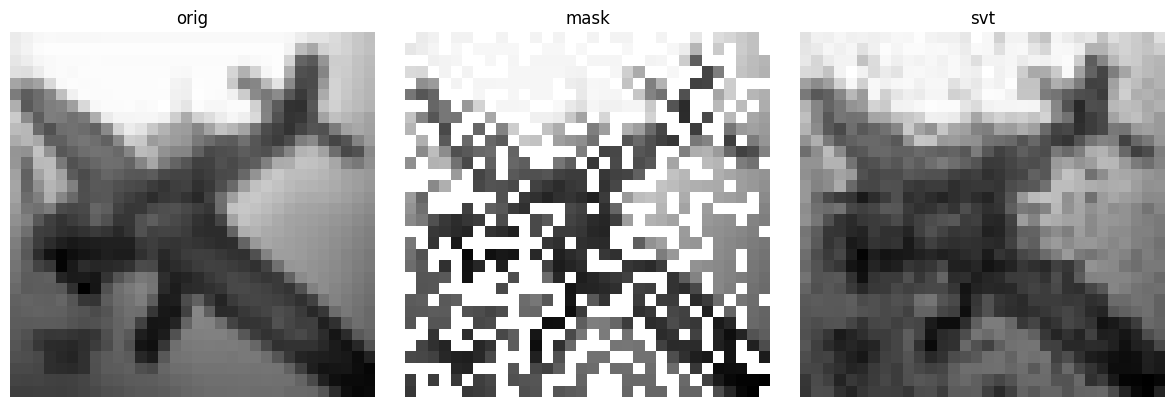

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(12,4))
for i, tag in enumerate(["orig", "mask", "svt"]):
    axs[i].imshow(Image.open(f"/content/results_cifar_mask_rate_40/img_027_{tag}.png"), cmap="gray")
    axs[i].set_title(tag); axs[i].axis("off")
plt.tight_layout()

In [ ]:
from google.colab import files
files.download('/content/results_cifar_mask_rate_40/summary.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## ***Mask Rate = 30%***

In [ ]:
!python svt_image_completion.py \
        --dataset cifar10 \
        --root /content/datasets \
        --mask random --mask-rate 0.3 \
        --max-images 50 \
        --max-dim 256 \
        --output /content/results_cifar_mask_rate_30

images: 100% 50/50 [00:43<00:00,  1.15it/s]

Processed 50 images. Avg PSNR: 25.78 dB; SSIM: 0.904


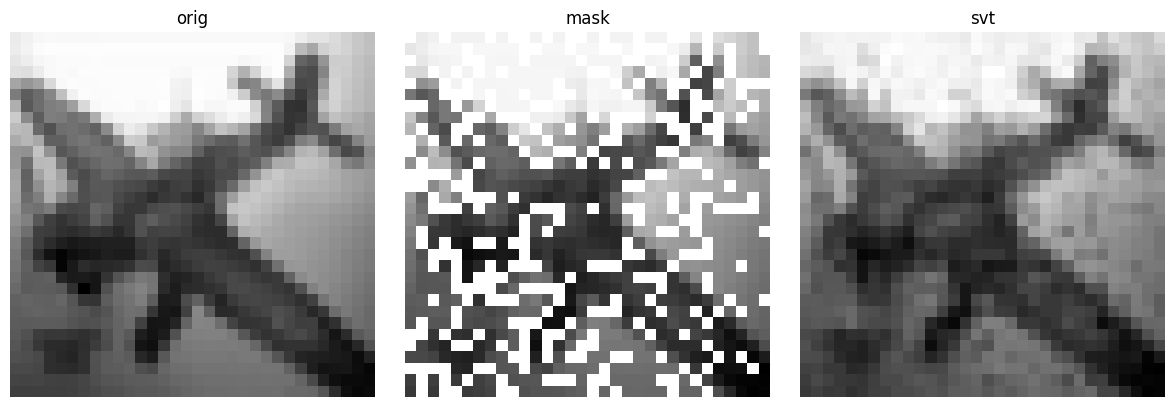

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(12,4))
for i, tag in enumerate(["orig", "mask", "svt"]):
    axs[i].imshow(Image.open(f"/content/results_cifar_mask_rate_30/img_027_{tag}.png"), cmap="gray")
    axs[i].set_title(tag); axs[i].axis("off")
plt.tight_layout()


In [ ]:
from google.colab import files
files.download('/content/results_cifar_mask_rate_30/summary.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# ***BSDS500***

---



In [ ]:
from google.colab import files
uploaded = files.upload()

Saving berkeley-segmentation-dataset-500-bsds500.zip to berkeley-segmentation-dataset-500-bsds500.zip


In [ ]:
%%bash
mkdir -p /content/datasets/bsds500
unzip -q /content/berkeley-segmentation-dataset-500-bsds500.zip -d /content/datasets/bsds500


In [ ]:
%%bash
mkdir -p /content/datasets/bsds500/all_images
cp /content/datasets/bsds500/images/train/* /content/datasets/bsds500/all_images/
cp /content/datasets/bsds500/images/val/* /content/datasets/bsds500/all_images/
cp /content/datasets/bsds500/images/test/* /content/datasets/bsds500/all_images/


## ***Mask Rate = 50%***

In [ ]:
!python svt_image_completion.py \
    --dataset bsds500 \
    --root /content/datasets/bsds500/all_images \
    --mask random --mask-rate 0.5 \
    --max-images 50 \
    --max-dim 128 \
    --output /content/results_bsds_mask_rate_50

images: 100% 50/50 [02:44<00:00,  3.28s/it]

Processed 50 images. Avg PSNR: 24.26 dB; SSIM: 0.751


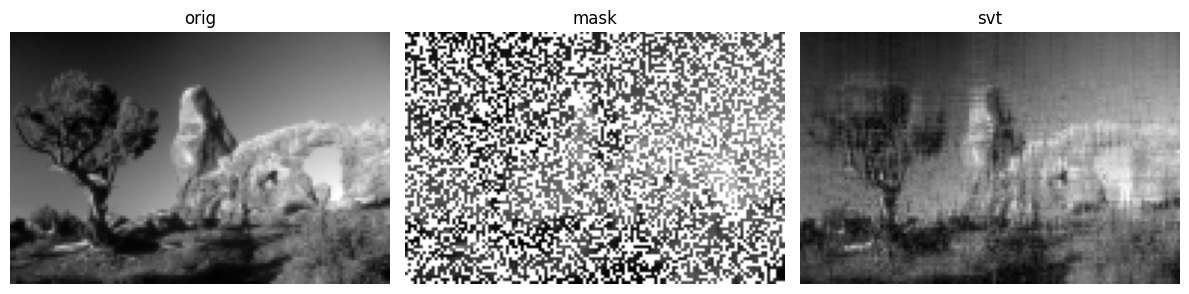

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(12,4))
for i, tag in enumerate(["orig", "mask", "svt"]):
    axs[i].imshow(Image.open(f"/content/results_bsds_mask_rate_50/img_027_{tag}.png"), cmap="gray")
    axs[i].set_title(tag); axs[i].axis("off")
plt.tight_layout()

## ***Mask Rate = 40%***

In [ ]:
!python svt_image_completion.py \
    --dataset bsds500 \
    --root /content/datasets/bsds500/all_images \
    --mask random --mask-rate 0.4 \
    --max-images 50 \
    --max-dim 128 \
    --output /content/results_bsds_mask_rate_40

images: 100% 50/50 [02:05<00:00,  2.50s/it]

Processed 50 images. Avg PSNR: 26.76 dB; SSIM: 0.835


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(12,4))
for i, tag in enumerate(["orig", "mask", "svt"]):
    axs[i].imshow(Image.open(f"/content/results_bsds_mask_rate_40/img_027_{tag}.png"), cmap="gray")
    axs[i].set_title(tag); axs[i].axis("off")
plt.tight_layout()

## ***Mask Rate = 30%***

In [ ]:
!python svt_image_completion.py \
    --dataset bsds500 \
    --root /content/datasets/bsds500/all_images \
    --mask random --mask-rate 0.3 \
    --max-images 50 \
    --max-dim 128 \
    --output /content/results_bsds_mask_rate_30

images: 100% 50/50 [01:55<00:00,  2.32s/it]

Processed 50 images. Avg PSNR: 27.48 dB; SSIM: 0.858


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(12,4))
for i, tag in enumerate(["orig", "mask", "svt"]):
    axs[i].imshow(Image.open(f"/content/results_bsds_mask_rate_30/img_027_{tag}.png"), cmap="gray")
    axs[i].set_title(tag); axs[i].axis("off")
plt.tight_layout()